In [1]:
pip install faker

In [2]:
from faker import Faker

In [3]:
import pandas as pd

In [4]:
import random

In [5]:
#Creamos una instancia de Faker
fake = Faker("es_MX")

In [6]:
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i+1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(["Instagram","Facebook","Twitter"])
    })

In [7]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Esmeralda Ibarra Tafoya,mariano19@example.net,31,41696,Facebook
1,2,Abril Romo Jasso,noriegasoledad@example.com,22,11058,Twitter
2,3,Elisa Andrea Reyes Guerra,yolanda19@example.com,27,35713,Instagram
3,4,Óscar Echeverría Sepúlveda,gomezgerardo@example.net,55,4525,Twitter
4,5,Ana Luisa Cantú Padrón,francisco92@example.org,30,20622,Twitter


In [8]:
#Exportacion del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [9]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,999,NaN,NaN,3
top,NaN,Estefanía Inés Toledo,qquiroz@example.net,NaN,NaN,Instagram
freq,NaN,1,2,NaN,NaN,354
mean,500.500000,NaN,NaN,41.464000,24243.946000,NaN
std,288.819436,NaN,NaN,13.742254,14401.368888,NaN
min,1.000000,NaN,NaN,18.000000,129.000000,NaN
25%,250.750000,NaN,NaN,29.000000,11377.750000,NaN
50%,500.500000,NaN,NaN,42.000000,24696.000000,NaN
75%,750.250000,NaN,NaN,53.000000,35852.250000,NaN


In [10]:
#Import librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

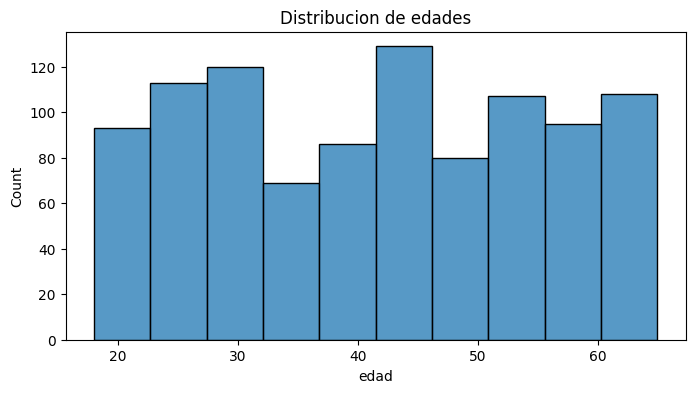

In [11]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(df["edad"], bins=10)
plt.title("Distribucion de edades")
plt.show()

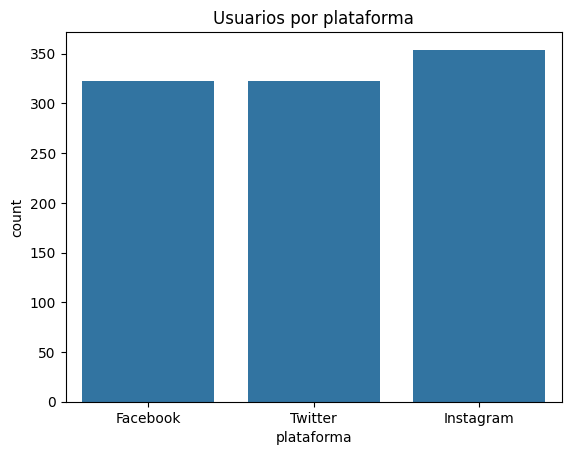

In [12]:
#Usuarios por plataforma
sns.countplot(x="plataforma", data=df)
plt.title("Usuarios por plataforma")
plt.show()

In [13]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [14]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
  df_sucio.loc[i,"nombre"] = None

In [15]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      995 non-null    object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [16]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
  df_sucio.loc[i,"edad"] = -10

In [17]:
df_sucio.describe()["edad"]

,edad
count,1000.000000
mean,41.181000
std,14.204225
min,-10.000000
25%,29.000000
50%,42.000000
75%,53.000000
max,65.000000


In [18]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
  df_sucio.loc[i,"seguidores"] = 5000000

In [19]:
df_sucio.describe()["seguidores"]

,seguidores
count,1.000000e+03
mean,4.914193e+04
std,3.514265e+05
min,1.290000e+02
25%,1.146450e+04
50%,2.482050e+04
75%,3.605025e+04
max,5.000000e+06


In [20]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)),5):
  df_sucio.loc[i,"correo"] = "correo_invalido"

In [21]:
df_sucio.describe(include=["string","object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,995,3
top,Estefanía Inés Toledo,correo_invalido,Instagram
freq,1,5,354


In [22]:
df_sucio.isnull().sum()

,0
id_usuario,0
nombre,5
correo,0
edad,0
seguidores,0
plataforma,0


In [23]:
#Estadistica
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,995,1000,1000.000000,1.000000e+03,1000
unique,NaN,995,995,NaN,NaN,3
top,NaN,Estefanía Inés Toledo,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,354
mean,500.500000,NaN,NaN,41.181000,4.914193e+04,NaN
std,288.819436,NaN,NaN,14.204225,3.514265e+05,NaN
min,1.000000,NaN,NaN,-10.000000,1.290000e+02,NaN
25%,250.750000,NaN,NaN,29.000000,1.146450e+04,NaN
50%,500.500000,NaN,NaN,42.000000,2.482050e+04,NaN
75%,750.250000,NaN,NaN,53.000000,3.605025e+04,NaN
